In [ ]:
!pip install -r requirements.txt

## Imports

In [1]:
# Common
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from matplotlib import rc
rc('axes', linewidth=1)

from functools import partial
from opt_einsum import contract

# Qutip
import qutip as qt
from qutip import Bloch, rand_ket_haar, rand_dm_hs

# Tensorcircuit
import tensorcircuit as tc
from tensorcircuit.densitymatrix import DMCircuit

import tensorcircuit.quantum as qu

K = tc.set_backend('pytorch')
tc.set_dtype('complex64')

# Pytorch
import torch
import torch.nn as nn

import ot

import time

import src.utils as utils
import src.loss_functions as lf
from src.models.forward_diffusion_model import ForwardDiffusionModel
from src.models.backward_denoising_model import BackwardDenoisingModel

## Clustered States

### Haar Ancillas

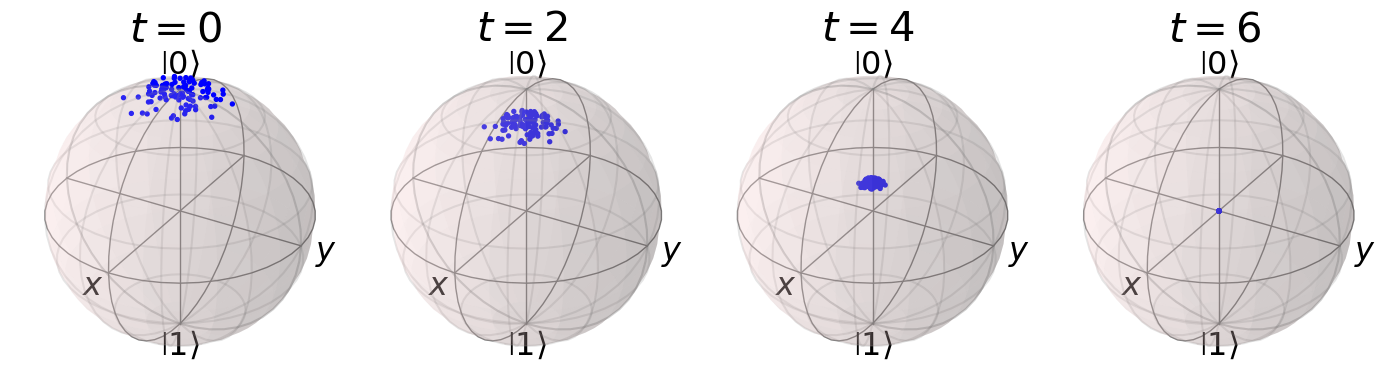

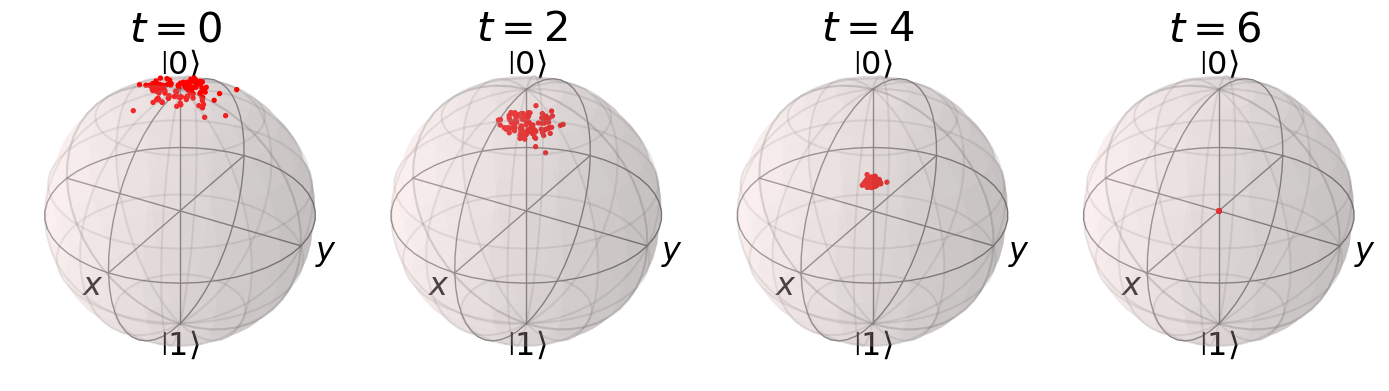

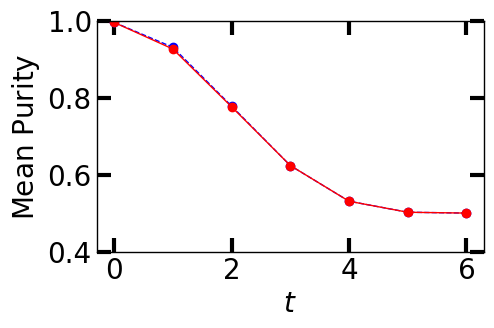

In [17]:
opt_params = np.load('data/cluster/T6L4WassHaarCosine_optParams.npy').tolist()

seed = None

jobID = None
max_epoch = 2001
n = 1
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 4
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
lr = 1e-2
lr_decay_rate = 0.5
lr_decay_count = 2
xavier_init = False
use_zero_ancillas = False
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'cluster'
compute_global_loss = True

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.08)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs[t] = forward_model.get_forward_density_matrices(t, init_dms)

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(T, -1, -1):
    backward_outputs[t] = backward_model.prepare_backward_states(t, inputs_backward, opt_params)[:, :2**n, :2**n]

utils.plot_forward_process_outputs(forward_outputs, T=T, n_data=n_train)
utils.plot_backward_process_outputs(backward_outputs, T, n_train)

utils.plot_purity(T, forward_outputs, backward_outputs)
# utils.plot_loss_history(loss_histories)

plt.show()
plt.close()

In [12]:
# 10 trials

opt_params = np.load('data/cluster/T6L4WassHaarCosine_optParams.npy').tolist()

# seed = None

jobID = None
max_epoch = 2001
n = 1
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 4
fixed_p = True
# p_limit = 0.2
p_limit = 1.
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
lr = 1e-2
lr_decay_rate = 0.5
lr_decay_count = 2
xavier_init = False
use_zero_ancillas = False
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'cluster'
compute_global_loss = True

fw_gloss = np.zeros(10)
bk_gloss = np.zeros(10)

for i in range(fw_gloss.shape[0]):
    init_dms = utils.get_initial_states(initial_type, n, n_data, epsilon = 0.08)
    
    dims = 2**n
    rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
    inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()
    
    backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
    backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
    backward_outputs[0] = backward_model.prepare_backward_states(0, inputs_backward, opt_params)[:, :2**n, :2**n]

    fw_gloss[i] = np.real(init_dms[:,0,0]).mean()
    bk_gloss[i] = np.real(backward_outputs[0, :, 0, 0]).mean()
    print(f"[set {i}] forward fidelity: {fw_gloss[i]}, backward fidelity: {bk_gloss[i]}")

print(f"data fidelity: mean {np.mean(fw_gloss)}, var: {np.var(fw_gloss)}")
print(f"gen fidelity: mean {np.mean(bk_gloss)}, var: {np.var(bk_gloss)}")

[set 0] forward fidelity: 0.9859829545021057, backward fidelity: 0.9868357181549072
[set 1] forward fidelity: 0.9855796694755554, backward fidelity: 0.9874257445335388
[set 2] forward fidelity: 0.9849634170532227, backward fidelity: 0.9869490265846252
[set 3] forward fidelity: 0.9840769171714783, backward fidelity: 0.986924946308136
[set 4] forward fidelity: 0.9857906699180603, backward fidelity: 0.9867445230484009
[set 5] forward fidelity: 0.9853449463844299, backward fidelity: 0.9855738878250122
[set 6] forward fidelity: 0.9852160811424255, backward fidelity: 0.9857670068740845
[set 7] forward fidelity: 0.9852632880210876, backward fidelity: 0.9844839572906494
[set 8] forward fidelity: 0.9852429628372192, backward fidelity: 0.9884744882583618
[set 9] forward fidelity: 0.9847626686096191, backward fidelity: 0.9880240559577942
data fidelity: mean 0.9852223575115204, var: 2.636723543858466e-07
gen fidelity: mean 0.986720335483551, var: 1.260696946161488e-06


### Zero Ancillas

In [21]:
opt_params = np.load('data/cluster/T6L4WassZeroCosine_optParams.npy').tolist()

jobID = None
max_epoch = 2001
n = 1
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 4
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
lr = 1e-2
lr_decay_rate = 0.5
lr_decay_count = 2
xavier_init = False
use_zero_ancillas = True
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'cluster'
compute_global_loss = True

fw_gloss = np.zeros(10)
bk_gloss = np.zeros(10)

for i in range(fw_gloss.shape[0]):
    init_dms = utils.get_initial_states(initial_type, n, n_data, epsilon = 0.08)
    
    dims = 2**n
    rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
    inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()
    
    backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
    backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
    backward_outputs[0] = backward_model.prepare_backward_states(0, inputs_backward, opt_params)[:, :2**n, :2**n]

    fw_gloss[i] = np.real(init_dms[:,0,0]).mean()
    bk_gloss[i] = np.real(backward_outputs[0, :, 0, 0]).mean()
    print(f"[set {i}] forward fidelity: {fw_gloss[i]}, backward fidelity: {bk_gloss[i]}")

print(f"data fidelity: mean {np.mean(fw_gloss)}, var: {np.var(fw_gloss)}")
print(f"gen fidelity: mean {np.mean(bk_gloss)}, var: {np.var(bk_gloss)}")

[set 0] forward fidelity: 0.9850797653198242, backward fidelity: 0.9886019825935364
[set 1] forward fidelity: 0.9852717518806458, backward fidelity: 0.988551914691925
[set 2] forward fidelity: 0.984998881816864, backward fidelity: 0.9886375665664673
[set 3] forward fidelity: 0.9851976037025452, backward fidelity: 0.98899245262146
[set 4] forward fidelity: 0.9850075840950012, backward fidelity: 0.9886466264724731
[set 5] forward fidelity: 0.9852898120880127, backward fidelity: 0.9884935021400452
[set 6] forward fidelity: 0.9846414923667908, backward fidelity: 0.988807737827301
[set 7] forward fidelity: 0.9845426082611084, backward fidelity: 0.9889731407165527
[set 8] forward fidelity: 0.9858807325363159, backward fidelity: 0.9885365962982178
[set 9] forward fidelity: 0.9855361580848694, backward fidelity: 0.9886021614074707
data fidelity: mean 0.9851446390151978, var: 1.3949944005275938e-07
gen fidelity: mean 0.9886843681335449, var: 2.8649613739162303e-08


## Circular States

### Zero Ancillas

[global loss] step 0, loss: 3.278255444882916e-09
[global loss] step 0, loss: 0.00019417941803112626
[global loss] step 0, loss: 0.006874725688248873
[global loss] step 0, loss: 0.038772352039813995
[global loss] step 0, loss: 0.11931487172842026
[global loss] step 0, loss: 0.26656895875930786
[global loss] step 0, loss: 0.4044387936592102
[global loss] step 0, loss: 0.4044387936592102
[global loss] step 0, loss: 0.3033815622329712
[global loss] step 0, loss: 0.1540919989347458
[global loss] step 0, loss: 0.0652763620018959
[global loss] step 0, loss: 0.0355873703956604
[global loss] step 0, loss: 0.015712568536400795
[global loss] step 0, loss: 0.017604123800992966


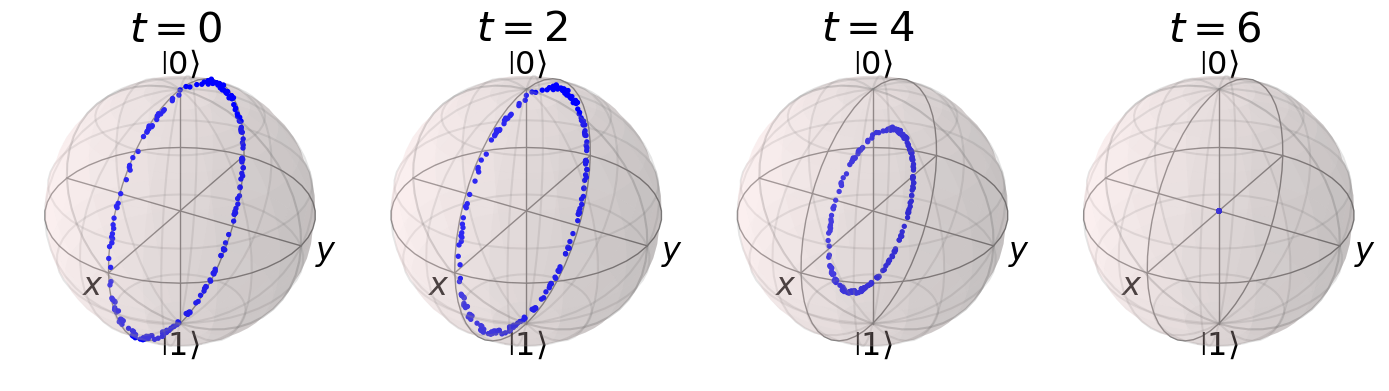

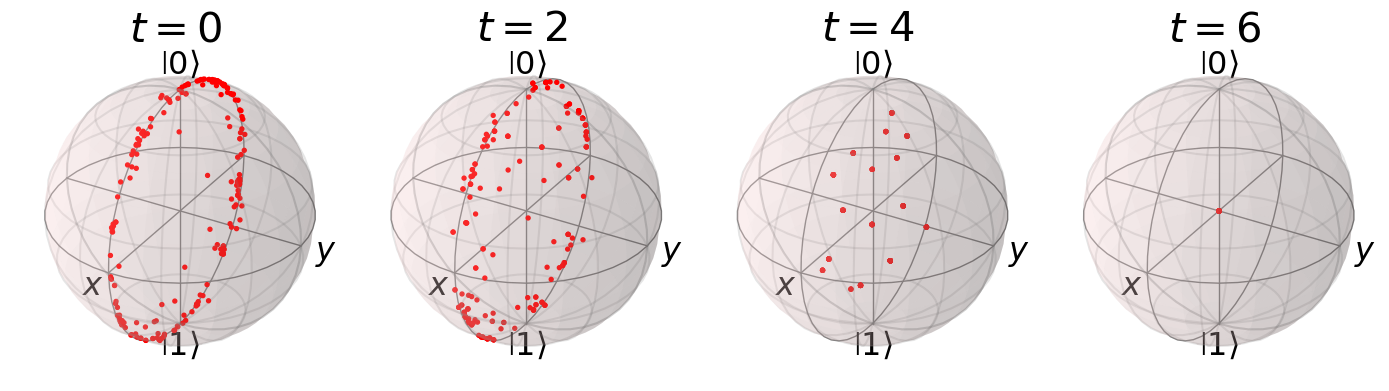

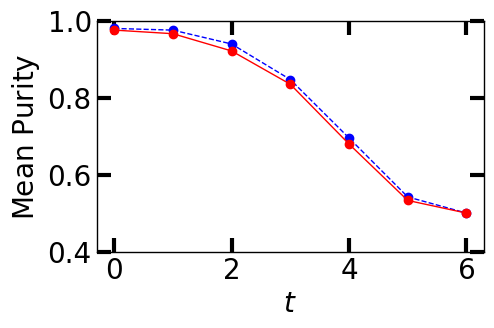

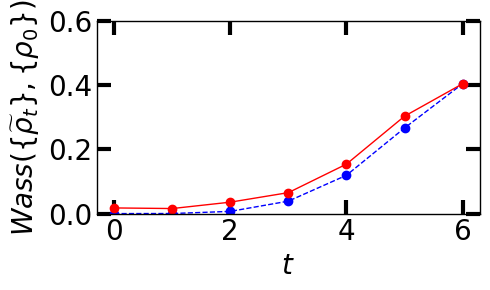

In [13]:
opt_params = np.load('data/circular/n1na2T6L8sq_cosineWass_optParams.npy').tolist()

jobID = None
max_epoch = 2001
n = 1
T = 6
n_data = 2000
n_train = 200
n_ancilla = 2
L = 8
beta_schedule = 'sq_cosine'
beta_start = 0.1
beta_end = 1.
lr = 7e-4
lr_decay_rate = 0.5
lr_decay_count = 4
xavier_init = False
use_zero_ancillas = True
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'circular'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

loss_fn_global = lf.get_loss_fn(loss_type, fidelity_type)
forward_global_losses = np.zeros(T+1)
backward_global_losses = np.zeros(T+1)
idxs = np.random.choice(n_train, size=n_train, replace=False)
initial_forward = torch.from_numpy(init_dms[idxs])

for t in range(0, T+1):
    forward_outputs[t] = forward_model.get_forward_density_matrices(t, init_dms)
    global_loss = loss_fn_global.forward(torch.from_numpy(forward_outputs[t]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    forward_global_losses[t] = (global_loss.item())

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(T, -1, -1):
    backward_outputs[t] = backward_model.prepare_backward_states(t, inputs_backward, opt_params)[:, :2**n, :2**n]
    global_loss = loss_fn_global.forward(torch.from_numpy(backward_outputs[t]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    backward_global_losses[t] = (global_loss.item())

utils.plot_forward_process_outputs(forward_outputs, T=T, n_data=n_train)
utils.plot_backward_process_outputs(backward_outputs, T, n_train)

def plot_wass_distance(T, forward_global_losses = None, backward_global_losses = None):
    fig, ax = plt.subplots(figsize=(5, 3))
    if forward_global_losses is not None:
        ax.plot(range(T+1), forward_global_losses, 'o--', lw=1, c='b')
    if backward_global_losses is not None:
        ax.plot(range(T+1), backward_global_losses, 'o-', lw=1, c='r')
    ax.set_ylabel(r'$Wass (\{\widetilde{\rho}_t\}, \{\rho_0\})$', fontsize=20)
    ax.set_xlabel(r'$t$', fontsize=20)
    ax.set_ylim(0,0.6)
    ax.tick_params(direction='in', length=10, width=3, top='on', right='on', labelsize=20)

utils.plot_purity(T, forward_outputs, backward_outputs)
plot_wass_distance(T, forward_global_losses, backward_global_losses)
# utils.plot_loss_history(loss_histories)
plt.tight_layout()
plt.show()
plt.close()

In [26]:
# 10 Trials

opt_params = np.load('data/circular/n1na2T6L8sq_cosineWass_optParams.npy').tolist()

jobID = None
max_epoch = 2001
n = 1
T = 6
n_data = 2000
n_train = 200
n_ancilla = 2
L = 8
beta_schedule = 'sq_cosine'
beta_start = 0.1
beta_end = 1.
lr = 7e-4
lr_decay_rate = 0.5
lr_decay_count = 4
xavier_init = False
use_zero_ancillas = True
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'circular'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

loss_fn_global = lf.get_loss_fn(loss_type, fidelity_type)
forward_global_losses = np.zeros(T+1)
backward_global_losses = np.zeros(T+1)
idxs = np.random.choice(n_train, size=n_train, replace=False)
initial_forward = torch.from_numpy(init_dms[idxs])
fw_gloss = np.zeros(10)
bk_gloss = np.zeros(10)

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

for i in range(fw_gloss.shape[0]):
    init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
    
    backward_outputs[0] = backward_model.prepare_backward_states(0, inputs_backward, opt_params)[:, :2**n, :2**n]

    fw_gloss[i] = loss_fn_global.forward(torch.from_numpy(init_dms), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    bk_gloss[i] = loss_fn_global.forward(torch.from_numpy(backward_outputs[0]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    print(f"[set {i}] forward wass: {fw_gloss[i]}, backward wass: {bk_gloss[i]}")

print(f"data wass: mean {np.mean(fw_gloss)}, var: {np.var(fw_gloss)}")
print(f"gen wass: mean {np.mean(bk_gloss)}, var: {np.var(bk_gloss)}")


[global loss] step 0, loss: 0.01123081985861063
[global loss] step 0, loss: 0.023234276100993156
[set 0] forward wass: 0.01123081985861063, backward wass: 0.023234276100993156
[global loss] step 0, loss: 0.0037231699097901583
[global loss] step 0, loss: 0.010498816147446632
[set 1] forward wass: 0.0037231699097901583, backward wass: 0.010498816147446632
[global loss] step 0, loss: 0.00413907878100872
[global loss] step 0, loss: 0.016399387270212173
[set 2] forward wass: 0.00413907878100872, backward wass: 0.016399387270212173
[global loss] step 0, loss: 0.005641949363052845
[global loss] step 0, loss: 0.013898826204240322
[set 3] forward wass: 0.005641949363052845, backward wass: 0.013898826204240322
[global loss] step 0, loss: 0.006916035898029804
[global loss] step 0, loss: 0.015892580151557922
[set 4] forward wass: 0.006916035898029804, backward wass: 0.015892580151557922
[global loss] step 0, loss: 0.014222361147403717
[global loss] step 0, loss: 0.015713214874267578
[set 5] forwar

### Haar Ancillas

[global loss] step 0, loss: 5.066394859198908e-09
[global loss] step 0, loss: 0.0025512906722724438
[global loss] step 0, loss: 0.053817424923181534
[global loss] step 0, loss: 0.21996767818927765
[global loss] step 0, loss: 0.40696239471435547
[global loss] step 0, loss: 0.40696239471435547
[global loss] step 0, loss: 0.2279900461435318
[global loss] step 0, loss: 0.07354235649108887
[global loss] step 0, loss: 0.02748073637485504
[global loss] step 0, loss: 0.015396647155284882


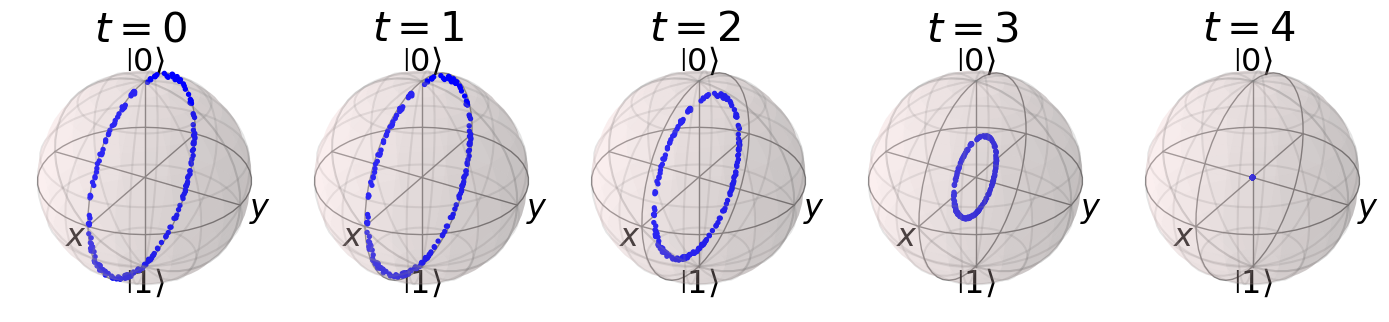

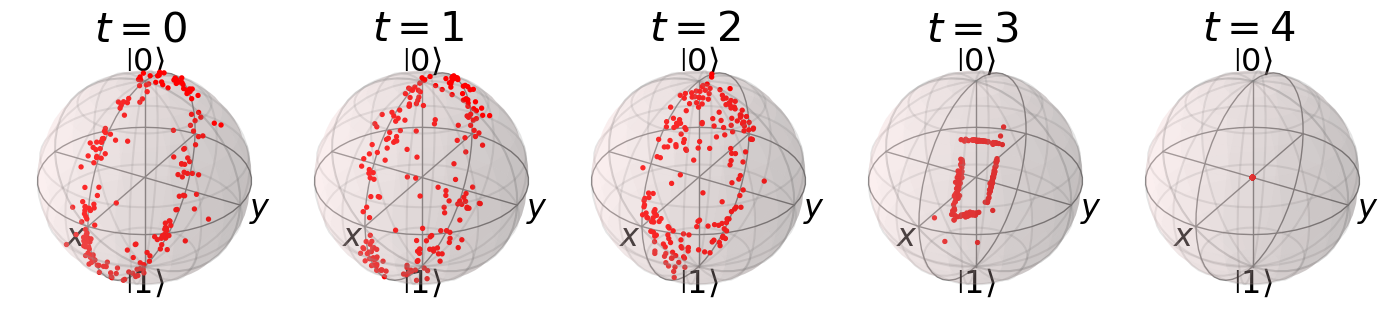

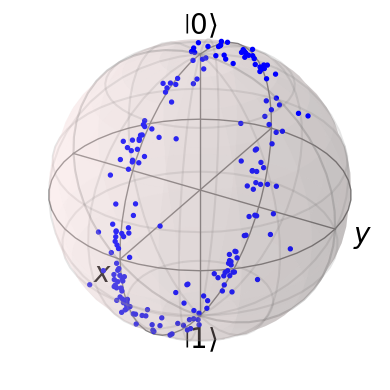

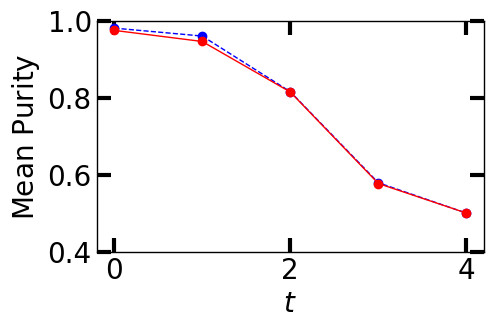

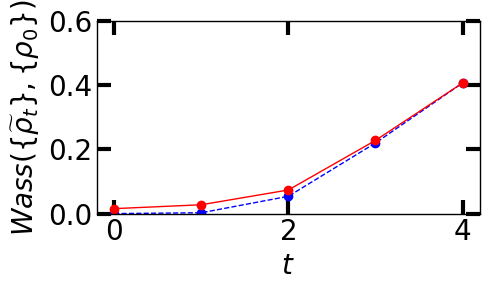

In [30]:
opt_params = np.load('data/circular/n1na2T4L8sq_cosineHaarWass_optParams.npy').tolist()

jobID = None
max_epoch = 2001
n = 1
T = 4
n_data = 2000
n_train = 200
n_ancilla = 2
L = 8
beta_schedule = 'sq_cosine'
beta_start = 0.1
beta_end = 1.
lr = 7e-4
lr_decay_rate = 0.5
lr_decay_count = 4
xavier_init = False
use_zero_ancillas = False
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'circular'
compute_global_loss = True

# Global Loss Coomputation with forward input t = 0
forward_global_losses = np.zeros(T+1)
backward_global_losses = np.zeros(T+1)

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

loss_fn_global = lf.get_loss_fn(loss_type, fidelity_type)
forward_global_losses = np.zeros(T+1)
backward_global_losses = np.zeros(T+1)
idxs = np.random.choice(n_train, size=n_train, replace=False)
initial_forward = torch.from_numpy(init_dms[idxs])

for t in range(0, T+1):
    forward_outputs[t] = forward_model.get_forward_density_matrices(t, init_dms)
    global_loss = loss_fn_global.forward(torch.from_numpy(forward_outputs[t]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    forward_global_losses[t] = (global_loss.item())

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(T, -1, -1):
    backward_outputs[t] = backward_model.prepare_backward_states(t, inputs_backward, opt_params)[:, :2**n, :2**n]
    global_loss = loss_fn_global.forward(torch.from_numpy(backward_outputs[t]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    backward_global_losses[t] = (global_loss.item())

utils.plot_forward_process_outputs(forward_outputs, T=T, n_data=n_train)
utils.plot_backward_process_outputs(backward_outputs, T, n_train)

utils.show_density_matrices(backward_outputs[0], ['b'])

utils.plot_purity(T, forward_outputs, backward_outputs)
plot_wass_distance(T, forward_global_losses, backward_global_losses)
# utils.plot_loss_history(loss_histories)
plt.tight_layout()
plt.show()
plt.close()

In [45]:
opt_params = np.load('data/circular/n1na2T4L8sq_cosineHaarWass_optParams.npy').tolist()

jobID = None
max_epoch = 2001
n = 1
T = 4
n_data = 2000
n_train = 200
n_ancilla = 2
L = 8
beta_schedule = 'sq_cosine'
beta_start = 0.1
beta_end = 1.
lr = 7e-4
lr_decay_rate = 0.5
lr_decay_count = 4
xavier_init = False
use_zero_ancillas = False
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'circular'
compute_global_loss = True

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

loss_fn_global = lf.get_loss_fn(loss_type, fidelity_type)
forward_global_losses = np.zeros(T+1)
backward_global_losses = np.zeros(T+1)
idxs = np.random.choice(n_train, size=n_train, replace=False)
initial_forward = torch.from_numpy(init_dms[idxs])
fw_gloss = np.zeros(10)
bk_gloss = np.zeros(10)

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

for i in range(fw_gloss.shape[0]):
    init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train, epsilon = 0.04)
    
    backward_outputs[0] = backward_model.prepare_backward_states(0, inputs_backward, opt_params)[:, :2**n, :2**n]

    fw_gloss[i] = loss_fn_global.forward(torch.from_numpy(init_dms), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    bk_gloss[i] = loss_fn_global.forward(torch.from_numpy(backward_outputs[0]), initial_forward, 0, params = None, rho_Ts = None, glob_loss = True)
    print(f"[set {i}] forward wass: {fw_gloss[i]}, backward wass: {bk_gloss[i]}")

print(f"data wass: mean {np.mean(fw_gloss)}, var: {np.var(fw_gloss)}")
print(f"gen wass: mean {np.mean(bk_gloss)}, var: {np.var(bk_gloss)}")


[global loss] step 0, loss: 0.011040452867746353
[global loss] step 0, loss: 0.011885483749210835
[set 0] forward wass: 0.011040452867746353, backward wass: 0.011885483749210835
[global loss] step 0, loss: 0.00460206251591444
[global loss] step 0, loss: 0.009297271259129047
[set 1] forward wass: 0.00460206251591444, backward wass: 0.009297271259129047
[global loss] step 0, loss: 0.004081389866769314
[global loss] step 0, loss: 0.011993132531642914
[set 2] forward wass: 0.004081389866769314, backward wass: 0.011993132531642914
[global loss] step 0, loss: 0.00607920391485095
[global loss] step 0, loss: 0.011167630553245544
[set 3] forward wass: 0.00607920391485095, backward wass: 0.011167630553245544
[global loss] step 0, loss: 0.0036633508279919624
[global loss] step 0, loss: 0.014140109531581402
[set 4] forward wass: 0.0036633508279919624, backward wass: 0.014140109531581402
[global loss] step 0, loss: 0.0065679410472512245
[global loss] step 0, loss: 0.010176174342632294
[set 5] forwa

## Many Body Phase

### Zero Ancillas

/opt/anaconda3/lib/python3.11/site-packages/qutip/bloch.py:752: RuntimeWarning: invalid value encountered in divide
  if any(abs(dist - dist[0]) / dist[0] > 1e-12):


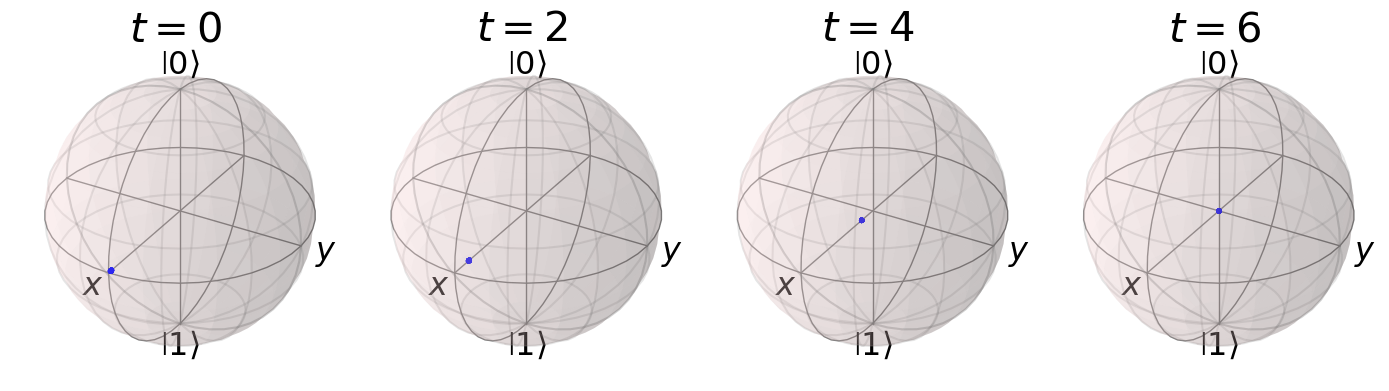

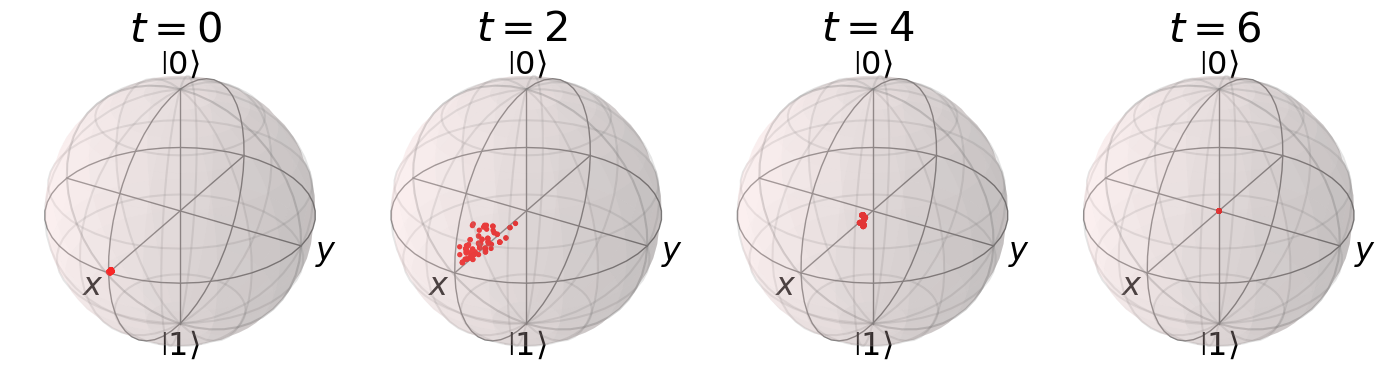

In [2]:
jobID = None

opt_params = np.load('data/many_body_phase/n4na2T6L12sq_cosineZeroMMD_optParams.npy').tolist()

max_epoch = 2001
n = 4
# T * L = 360
T = 6
n_data = 1000
n_train= 100
n_ancilla = 2
L = 12
beta_start = 0.1
beta_end = 1.0
beta_schedule = 'sq_cosine'
lr = 0.009
lr_decay_rate = 0.5
lr_decay_count = 2
xavier_init = False
use_zero_ancillas = True
fidelity_type = 'super'
loss_type = 'mmd'
initial_type = 'many_body_phase'
calculate_global_loss = False

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)

idxs = np.random.choice(n_train, size=n_train, replace=False)
initial_forward = torch.from_numpy(init_dms[idxs])

for t in range(0, T+1):
    forward_outputs[t] = forward_model.get_forward_density_matrices(t, init_dms)

dims = 2**n
rho_T_tildas = np.asarray([1. / dims * np.eye(dims) for _ in range(n_data)], dtype = np.complex64)
inputs_backward = torch.from_numpy(rho_T_tildas[:n_train]).cfloat()

backward_model = BackwardDenoisingModel(n, n_ancilla, T, L, use_zero_ancillas)
backward_outputs = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(T, -1, -1):
    backward_outputs[t] = backward_model.prepare_backward_states(t, inputs_backward, opt_params)[:, :2**n, :2**n]

utils.plot_forward_process_outputs(forward_outputs, T=T, n_data=n_train)
utils.plot_backward_process_outputs(backward_outputs, T, n_train)

plt.tight_layout()
plt.show()
plt.close()

/var/folders/2p/8nbljzbd5cl0v4lj4zb068280000gn/T/ipykernel_52672/1393489651.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  mag_back[t, i] = utils.get_magnetization(backward_outputs[t, i], n)
/var/folders/2p/8nbljzbd5cl0v4lj4zb068280000gn/T/ipykernel_52672/1393489651.py:11: ComplexWarning: Casting complex values to real discards the imaginary part
  mag_for[t, i] = utils.get_magnetization(forward_outputs[t, i], n)


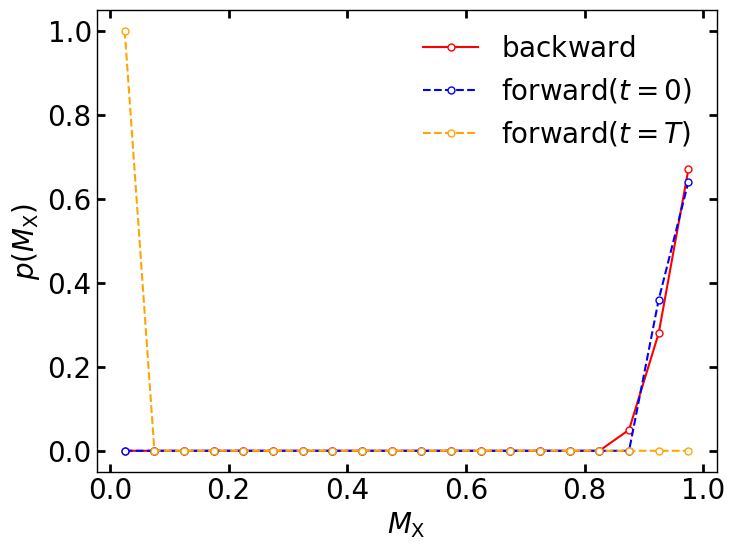

forward magnetization: 0.9523248801380396, var: 3.3473941830509507e-05
backward magnetization: 0.9392431548098102, var: 0.0005317684729563225


In [6]:
# calculate magnetization

mag_back = np.zeros((T+1, n_train))
for t in range(T+1):
    for i in range(n_train):
        mag_back[t, i] = utils.get_magnetization(backward_outputs[t, i], n)

mag_for = np.zeros((T+1, n_train))
for t in range(T+1):
    for i in range(n_train):
        mag_for[t, i] = utils.get_magnetization(forward_outputs[t, i], n)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
bins = np.linspace(0, 1, 21)

h_back, _ = np.histogram(mag_back[0], bins=bins)
ax.plot((bins[1:] + bins[:-1])/2, h_back/n_train, 'o-', c='r', mfc='white', markersize=5, label=r'$\rm backward$')

h0, _ = np.histogram(mag_for[0], bins=bins)
ax.plot((bins[1:] + bins[:-1])/2, h0/n_train, 'o--', c='b', mfc='white', markersize=5, label=r'${\rm forward}(t=0)$')
hT, _ = np.histogram(mag_for[6], bins=bins)
ax.plot((bins[1:] + bins[:-1])/2, hT/n_train, 'o--', c='orange', mfc='white', markersize=5, label=r'${\rm forward}(t=T)$')

ax.legend(fontsize=20, framealpha=0)
ax.set_xlabel(r'$M_{\rm X}$', fontsize=20)
ax.set_ylabel(r'$p(M_{\rm X})$', fontsize=20)
ax.tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=20)

plt.show()
plt.close()

print(f"forward magnetization: {mag_for[0].mean()}, var: {mag_for[0].var()}")
print(f"backward magnetization: {mag_back[0].mean()}, var: {mag_back[0].var()}")

### Forward Scheduling Comparison

In [2]:
def get_purity(x):
    return np.mean(np.trace(np.matmul(x, x), axis1=-2, axis2=-1))

def get_purities(model_outputs):
    purities = []
    for t in range(T+1):
        purities.append(get_purity(model_outputs[t]))
    return purities

def compare_purities(T, forward_output_cosine_n4, forward_output_sq_cosine_n4, forward_outputs_mbp_linear, title = None):
    fig, ax = plt.subplots(figsize=(8, 6))
    purity_n4_linear = get_purities(forward_outputs_mbp_linear)
    ax.plot(range(T+1), purity_n4_linear, 'o--', lw=1, c='gray', label='linear')
    purity_n4_cos = get_purities(forward_output_cosine_n4)
    ax.plot(range(T+1), purity_n4_cos, 'o--', lw=1, c='green', label='cosine')
    purity_n4_sq_cos = get_purities(forward_output_sq_cosine_n4)
    ax.plot(range(T+1), purity_n4_sq_cos, 'o-', lw=1, c='purple', label='sq cosine')
    ax.legend(fontsize=23, framealpha=0, fancybox=True)
    ax.set_ylabel(r'$\text{Mean Purity}(\{\rho_t\})$', fontsize=23)
    ax.set_xlabel(r'$t$', fontsize=23)
    ax.set_ylim(0,1)
    if title is not None:
        ax.set_title(title, fontsize=25)
    ax.tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=20)

def compare_fw_scheduling(fig, axs, l_histories, param_size, l_histories2 = None, param_size2 = None, l_histories3 = None, param_size3 = None):
    # plot training loss history
    loss_hist = np.array(l_histories)
    loss_hist_x = np.arange(0, len(l_histories) * param_size, param_size)
    axs.plot(loss_hist_x,loss_hist, '--', c='gray', mfc='white', markersize=0, linewidth=1, label=r'${\rm linear}$')
    if l_histories2 is not None:
        loss_hist = np.array(l_histories2)
        loss_hist_x = np.arange(0, len(l_histories2) * param_size2, param_size2)
        axs.plot(loss_hist_x,loss_hist, '--', c='green', mfc='white', markersize=0, linewidth=1, label=r'${\rm cosine}$')
    if l_histories3 is not None:
        loss_hist = np.array(l_histories3)
        loss_hist_x = np.arange(0, len(l_histories3) * param_size3, param_size3)
        axs.plot(loss_hist_x,loss_hist, '--', c='purple', mfc='white', markersize=0, linewidth=1, label=r'${\rm sq_ cosine}$')
    
    axs.legend(fontsize=23, framealpha=0)
    axs.tick_params(direction='in', length=6, width=2, top='on', right='on', labelsize=23)
    fig.supxlabel(r'$\rm iterations $', fontsize=23)
    fig.supylabel(r'$D_{\rm MMD}(\{\tilde{\rho}_t\}, \{\rho_0\})$', fontsize=23)
    plt.show()
    plt.close()

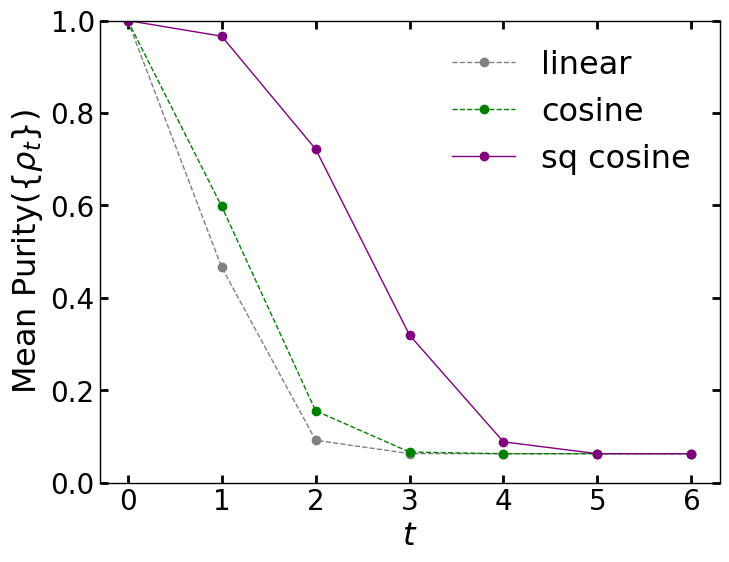

In [14]:

max_epoch = 2001
n = 4
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 12
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
fidelity_type = 'super'
loss_type = 'mmd'
initial_type = 'many_body_phase'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'linear'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_linear = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_linear[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'sq_cosine'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_sq_cos = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_sq_cos[t] = forward_model.get_forward_density_matrices(t, init_dms)

compare_purities(T, forward_outputs_mbp, forward_outputs_mbp_sq_cos, forward_outputs_mbp_linear)
plt.show()
plt.close()

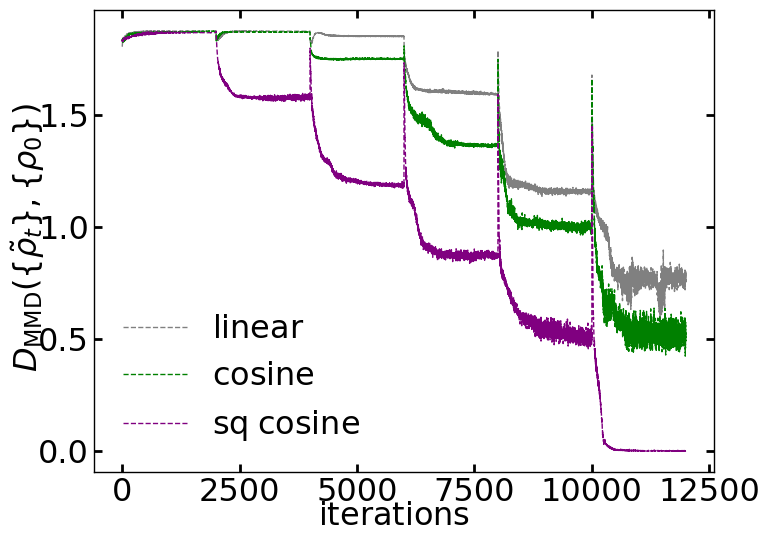

In [12]:
gLosses_linear = np.load('data/many_body_phase/n4na2T6L12linearZeroMMD_globalLosses.npy')
gLosses_cos = np.load('data/many_body_phase/n4na2T6L12cosineZeroMMD_globalLosses.npy')
gLosses_sqcos = np.load('data/many_body_phase/n4na2T6L12sq_cosineZeroMMD_globalLosses.npy')
fig, axs = plt.subplots(figsize=(8, 6))
compare_fw_scheduling(fig, axs, gLosses_linear, 1, gLosses_cos, 1, gLosses_sqcos, 1)

### Diffusion Steps Comparison

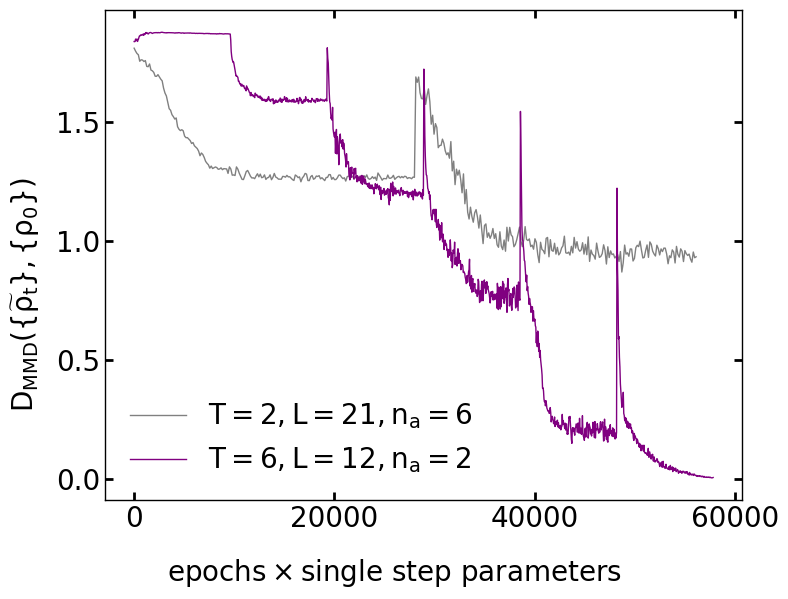

In [6]:
global_losses_small = np.load('data/many_body_phase/n4na6ndata500T2L21sq_cosineZeroMMD_globalLosses.npy').tolist()
global_losses_multi = np.load('data/many_body_phase/n4na2ndata500T6L12sq_cosineZeroMMD_globalLosses.npy').tolist()
fig, axs = plt.subplots(1, 1, figsize=(8, 6))
utils.plot_global_loss_history_iter(fig, axs, global_losses_small, 140, global_losses_multi, 48)

### Forward noising process comparison

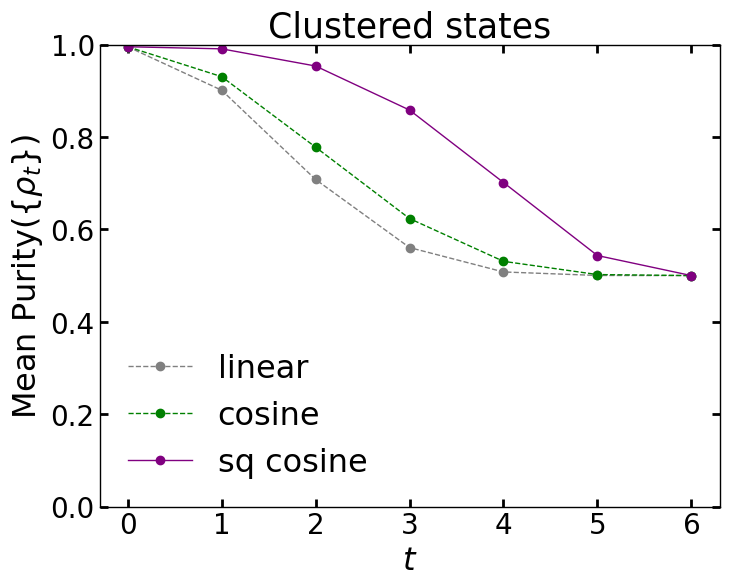

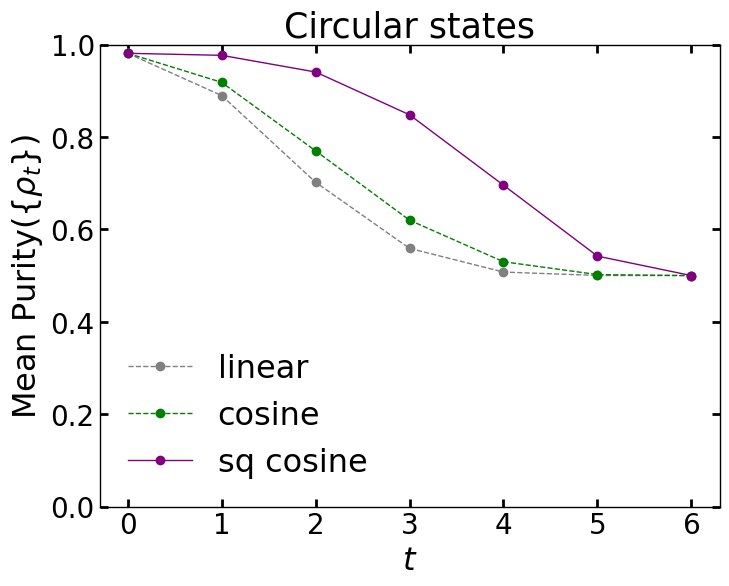

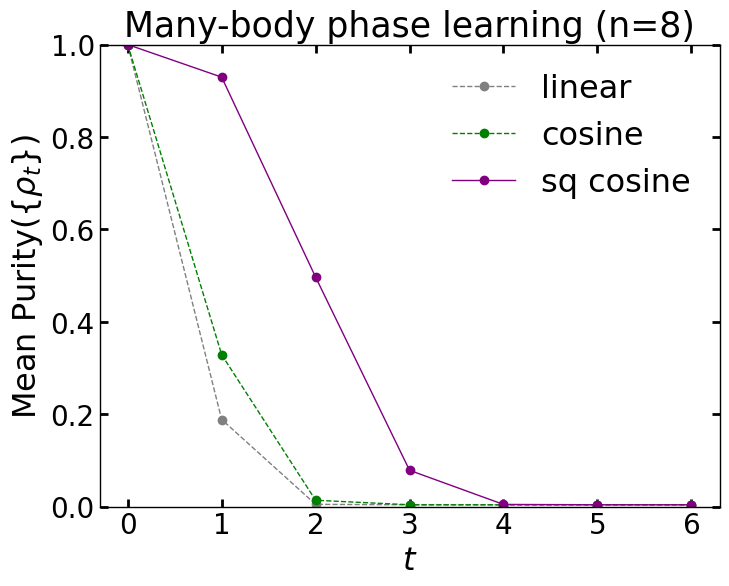

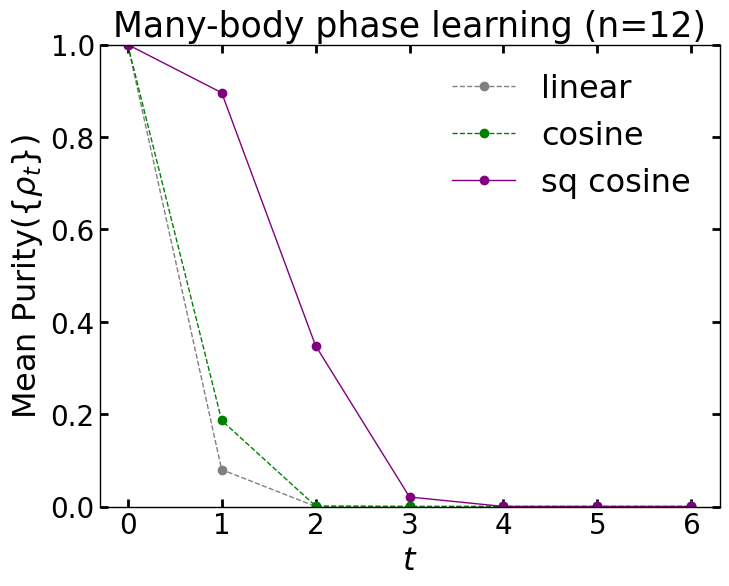

In [11]:
# Cluster
max_epoch = 2001
n = 1
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 12
fixed_p = True
# p_limit = 0.2
p_limit = 1.
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'cluster'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_cluster = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_cluster[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'linear'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_cluster_linear = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_cluster_linear[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'sq_cosine'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_cluster_sq_cos = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_cluster_sq_cos[t] = forward_model.get_forward_density_matrices(t, init_dms)

compare_purities(T, forward_outputs_cluster, forward_outputs_cluster_sq_cos, forward_outputs_cluster_linear, 'Clustered states')
plt.show()

# Circular
max_epoch = 2001
n = 1
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 12
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'circular'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_circular = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_circular[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'linear'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_circular_linear = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_circular_linear[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'sq_cosine'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_circular_sq_cos = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_circular_sq_cos[t] = forward_model.get_forward_density_matrices(t, init_dms)

compare_purities(T, forward_outputs_circular, forward_outputs_circular_sq_cos, forward_outputs_circular_linear, 'Circular states')
plt.show()

# MBP n=8

max_epoch = 2001
n = 8
T = 6
n_data = 1000
n_train = 100
n_ancilla = 2
L = 12
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'many_body_phase'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'linear'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_linear = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_linear[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'sq_cosine'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_sq_cos = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_sq_cos[t] = forward_model.get_forward_density_matrices(t, init_dms)

compare_purities(T, forward_outputs_mbp, forward_outputs_mbp_sq_cos, forward_outputs_mbp_linear, 'Many-body phase learning (n=8)')
plt.show()

# MBP n=12. This takes long time..
max_epoch = 2001
n = 12
T = 6
n_data = 50
n_train = 5
n_ancilla = 2
L = 12
beta_schedule = 'cosine'
beta_start = 0.1
beta_end = 1.
fidelity_type = 'super'
loss_type = 'wasserstein'
initial_type = 'many_body_phase'

init_dms = utils.get_initial_states(initial_type, n=n, n_data=n_train)
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'linear'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_linear = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_linear[t] = forward_model.get_forward_density_matrices(t, init_dms)

beta_schedule = 'sq_cosine'
forward_model = ForwardDiffusionModel(n, T, n_train, beta_start = beta_start, beta_end = beta_end, beta_schedule = beta_schedule)
forward_outputs_mbp_sq_cos = np.zeros((T+1, n_train, 2**n, 2**n), dtype=np.complex64)
for t in range(0, T+1):
    forward_outputs_mbp_sq_cos[t] = forward_model.get_forward_density_matrices(t, init_dms)

compare_purities(T, forward_outputs_mbp, forward_outputs_mbp_sq_cos, forward_outputs_mbp_linear, 'Many-body phase learning (n=12)')
plt.show()
plt.close()